#### **ANTES CON ROUTING**

In [1]:
import random
from typing import Literal #Esto es para indicar que el output solo puede ser uno de los valores indicados

from typing import TypedDict

class State(TypedDict):
    customer_name: str
    my_age: int

def node_1(state: State):  
    return state

def node_2(state: State):  
    return state

def node_3(state: State):  
    return state

def route_edge(state: State) -> Literal["node_2", "node_3"]:
    if random.random() < 0.5:
        return "node_2"
    return "node_3"

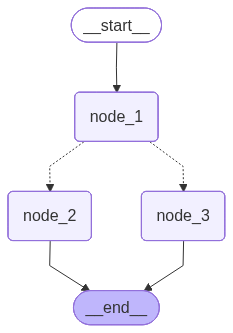

In [3]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

builder = StateGraph(State)
# Se crean los nodos
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Se hacen los edges
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", route_edge)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

agent = builder.compile()
display(Image(agent.get_graph().draw_mermaid_png()))

#### AHORA CON PARALLEIZATION

In [6]:
import random
from typing import Literal #Esto es para indicar que el output solo puede ser uno de los valores indicados

from typing import TypedDict

class State(TypedDict):
    customer_name: str
    my_age: int

def node_1(state: State):  
    return state

def node_2(state: State):  
    return state

def node_3(state: State):  
    return state

# Esto combina los resultados de los resultados de los nodos ejecutados en paralelo
def agregator(state: State):
    return state

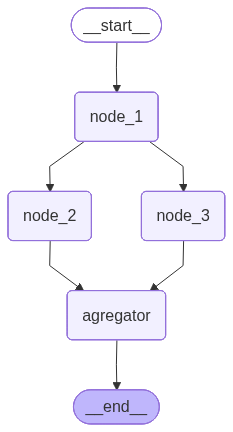

In [7]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

builder = StateGraph(State)
# Se crean los nodos
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)
builder.add_node("agregator", agregator)

# Se hacen los edges
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_1", "node_3")
builder.add_edge("node_2", "agregator")
builder.add_edge("node_3", "agregator")
builder.add_edge("agregator", END)

agent = builder.compile()
display(Image(agent.get_graph().draw_mermaid_png()))

Así como se hizo en Routing, para Parallelization es posible iniciar la paralelización desd el nodo START, o también se puede hacer que la paralelización inicie desde cualquier nodo del grafo:

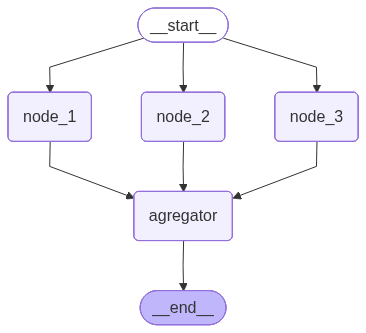

In [8]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

builder = StateGraph(State)
# Se crean los nodos
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)
builder.add_node("agregator", agregator)

# Se hacen los edges
builder.add_edge(START, "node_1")
builder.add_edge(START, "node_2")
builder.add_edge(START, "node_3")
builder.add_edge("node_1", "agregator")
builder.add_edge("node_2", "agregator")
builder.add_edge("node_3", "agregator")
builder.add_edge("agregator", END)

agent = builder.compile()
display(Image(agent.get_graph().draw_mermaid_png()))